# Project Workflow

```text
Crop Disease Dataset
        |
        ↓
Data Understanding
        |
        ↓
Data Cleaning & Preprocessing
        |
        ↓
Exploratory Data Analysis (EDA)
        |
        ↓
Feature Engineering
        |
        ↓
Feature Selection
        |
        ↓
Data Splitting
        |
        ↓
Data Preprocessing Pipeline
        |
        ↓
Random Forest Classification
        |
        ↓
Model Evaluation
        |
        ↓
Confusion Matrix
        |
        ↓
ROC-AUC Curve
        |
        ↓
Feature Importance
        |
        ↓
Sample Prediction
        |
        ↓
Save Model
        |
        ↓
Conclusion

# 1. Import Packages

In [1]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay)
print("Libraries imported successfully.")

Libraries imported successfully.


# 2. Read Dataset

In [2]:
file_path = r"C:\Users\hp\Downloads\crop_health_random_forest_dataset_20000.csv"

df = pd.read_csv(file_path)

print("Dataset Loaded Successfully")


Dataset Loaded Successfully


In [3]:
df.shape

(20000, 15)

In [4]:
df.head()

,Crop_Type,Temperature_C,Humidity_pct,Rainfall_mm,Soil_Moisture_pct,Soil_pH,Nitrogen_ppm,Phosphorus_ppm,Potassium_ppm,Sunlight_Hours,Wind_Speed_kmh,Pest_Pressure,Irrigation_Frequency_per_Week,Fertilizer_Usage_kg_per_ha,Disease_Present
0,Soybean,29.2,78.1,99.9,73.8,6.07,16.3,46.6,70.4,7.6,18.8,58.0,4,107.4,1
1,Cotton,29.5,59.9,75.9,41.5,6.08,39.6,32.0,71.3,5.7,12.7,18.6,5,134.7,1
2,Wheat,23.6,73.2,269.4,82.0,5.89,48.3,22.9,51.6,6.4,18.1,40.6,6,86.5,0
3,Cotton,17.4,87.4,67.3,70.0,7.08,67.3,47.2,56.3,5.4,10.4,30.5,6,87.8,1
4,Tomato,37.8,71.8,31.3,34.8,5.00,10.0,67.1,55.9,8.1,10.1,38.0,1,118.7,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Crop_Type                      20000 non-null  object 
 1   Temperature_C                  20000 non-null  float64
 2   Humidity_pct                   20000 non-null  float64
 3   Rainfall_mm                    20000 non-null  float64
 4   Soil_Moisture_pct              20000 non-null  float64
 5   Soil_pH                        20000 non-null  float64
 6   Nitrogen_ppm                   20000 non-null  float64
 7   Phosphorus_ppm                 20000 non-null  float64
 8   Potassium_ppm                  20000 non-null  float64
 9   Sunlight_Hours                 20000 non-null  float64
 10  Wind_Speed_kmh                 20000 non-null  float64
 11  Pest_Pressure                  20000 non-null  float64
 12  Irrigation_Frequency_per_Week  20000 non-null 

In [6]:
df.describe()

,Temperature_C,Humidity_pct,Rainfall_mm,Soil_Moisture_pct,Soil_pH,Nitrogen_ppm,Phosphorus_ppm,Potassium_ppm,Sunlight_Hours,Wind_Speed_kmh,Pest_Pressure,Irrigation_Frequency_per_Week,Fertilizer_Usage_kg_per_ha,Disease_Present
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,26.977015,67.945555,133.905030,59.214060,6.504125,55.219880,35.170460,44.961030,6.997435,12.074270,39.901755,4.010700,94.993375,0.566300
std,4.950077,13.626260,74.435932,20.542074,0.635690,19.845881,13.689237,17.864514,1.680184,4.910105,13.506063,1.997745,34.385567,0.495597
min,15.000000,30.000000,10.000000,15.000000,5.000000,10.000000,5.000000,5.000000,3.000000,1.000000,0.000000,1.000000,20.000000,0.000000
25%,23.500000,58.700000,77.800000,43.600000,6.070000,41.400000,25.800000,32.700000,5.800000,8.700000,30.800000,2.000000,71.400000,0.000000
50%,27.000000,68.100000,120.600000,58.500000,6.500000,55.200000,35.000000,44.900000,7.000000,12.000000,39.950000,4.000000,94.800000,1.000000
75%,30.400000,77.500000,175.900000,75.900000,6.930000,68.825000,44.300000,57.100000,8.200000,15.400000,49.100000,6.000000,118.200000,1.000000
max,40.000000,95.000000,350.000000,90.000000,8.000000,120.000000,80.000000,100.000000,11.000000,30.000000,90.900000,7.000000,200.000000,1.000000


In [7]:
df.isnull().sum()

Crop_Type                        0
Temperature_C                    0
Humidity_pct                     0
Rainfall_mm                      0
Soil_Moisture_pct                0
Soil_pH                          0
Nitrogen_ppm                     0
Phosphorus_ppm                   0
Potassium_ppm                    0
Sunlight_Hours                   0
Wind_Speed_kmh                   0
Pest_Pressure                    0
Irrigation_Frequency_per_Week    0
Fertilizer_Usage_kg_per_ha       0
Disease_Present                  0
dtype: int64

# 3. Data Preprocessing

In [8]:
# Create a modeling copy
model_df = df.copy()

# Remove exact duplicate rows if any
model_df = model_df.drop_duplicates().reset_index(drop=True)

# Ensure target is integer
model_df["Disease_Present"] = model_df["Disease_Present"].astype(int)

print("Rows after duplicate removal:", len(model_df))
print("Missing values after validation:", model_df.isnull().sum().sum())

Rows after duplicate removal: 20000
Missing values after validation: 0


# 4. Exploratory Data Analysis (EDA)



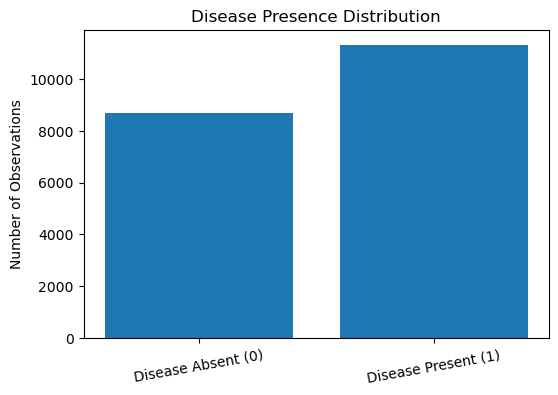

In [9]:
# Disease distribution

target_counts = model_df["Disease_Present"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["Disease Absent (0)", "Disease Present (1)"], target_counts.values)
plt.title("Disease Presence Distribution")
plt.ylabel("Number of Observations")
plt.xticks(rotation=10)
plt.show()

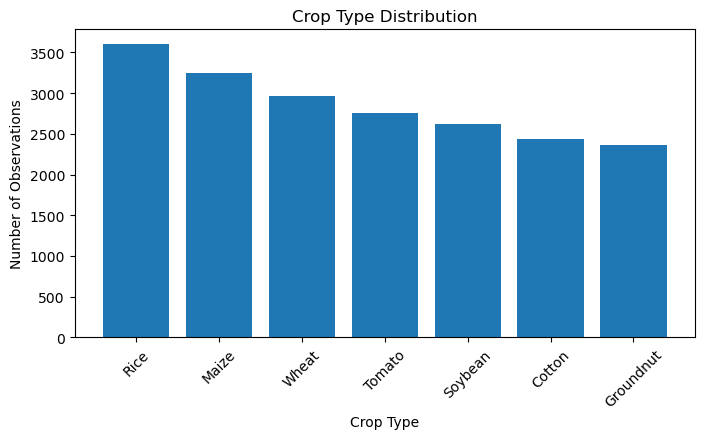

In [10]:
# Crop type distribution

crop_counts = model_df["Crop_Type"].value_counts()

plt.figure(figsize=(8, 4))
plt.bar(crop_counts.index, crop_counts.values)
plt.title("Crop Type Distribution")
plt.xlabel("Crop Type")
plt.ylabel("Number of Observations")
plt.xticks(rotation=45)
plt.show()

,count,mean,Disease_Rate_%
Crop_Type,,,
Tomato,2758,0.579405,57.940537
Soybean,2621,0.577642,57.764212
Maize,3245,0.569492,56.949153
Cotton,2442,0.565111,56.511057
Wheat,2968,0.560647,56.064690
Groundnut,2364,0.558376,55.837563
Rice,3602,0.555802,55.580233


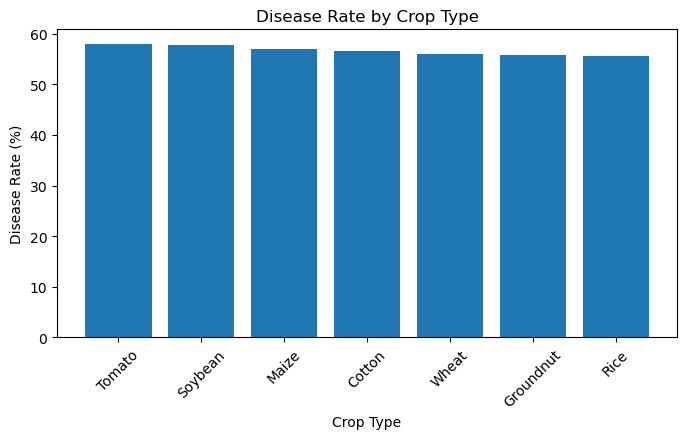

In [11]:
# Disease rate by crop type

crop_disease = (model_df.groupby("Crop_Type")["Disease_Present"].agg(["count", "mean"]).sort_values("mean", ascending=False))
crop_disease["Disease_Rate_%"] = crop_disease["mean"] * 100

display(crop_disease)

plt.figure(figsize=(8, 4))
plt.bar(crop_disease.index, crop_disease["Disease_Rate_%"])
plt.title("Disease Rate by Crop Type")
plt.xlabel("Crop Type")
plt.ylabel("Disease Rate (%)")
plt.xticks(rotation=45)
plt.show()

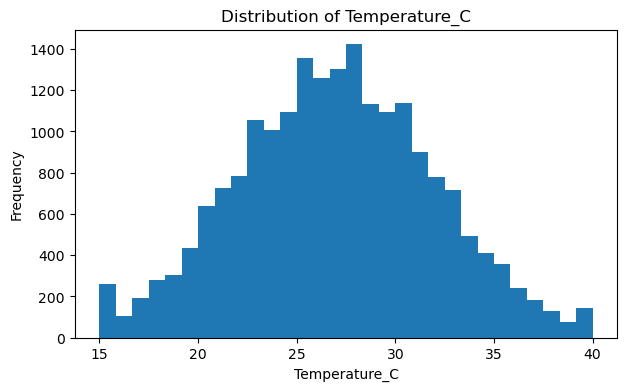

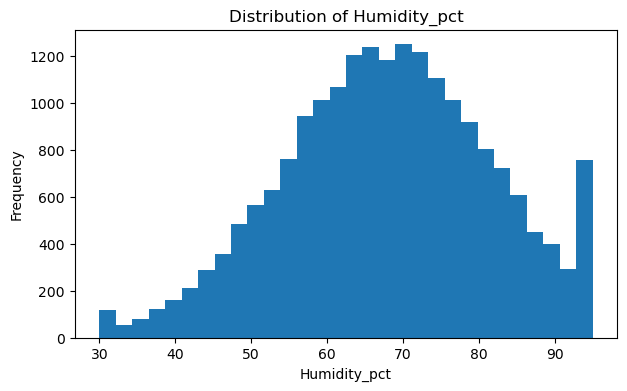

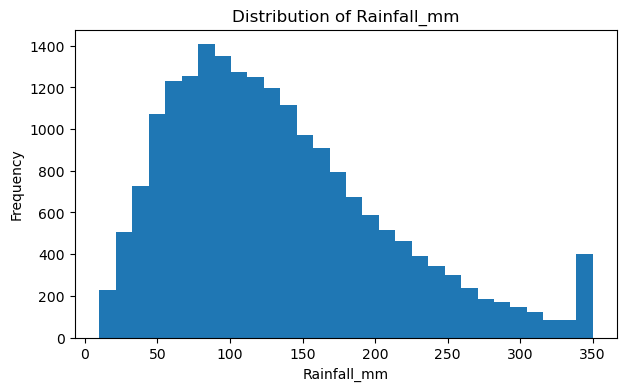

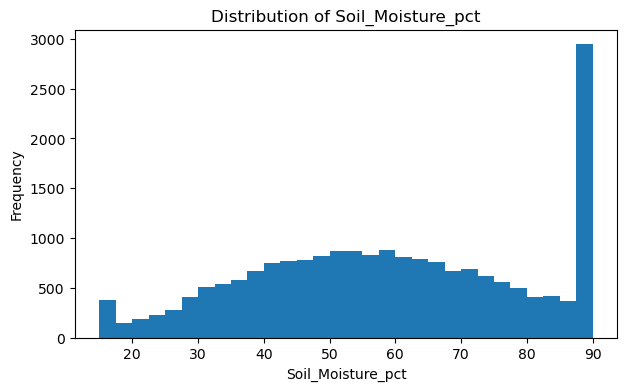

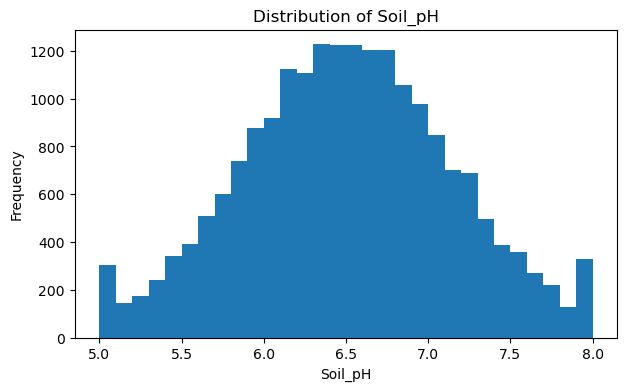

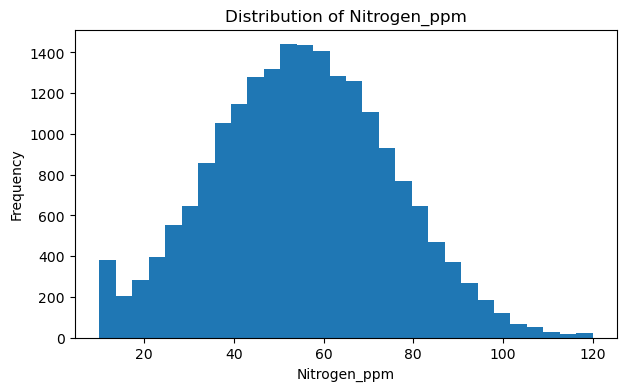

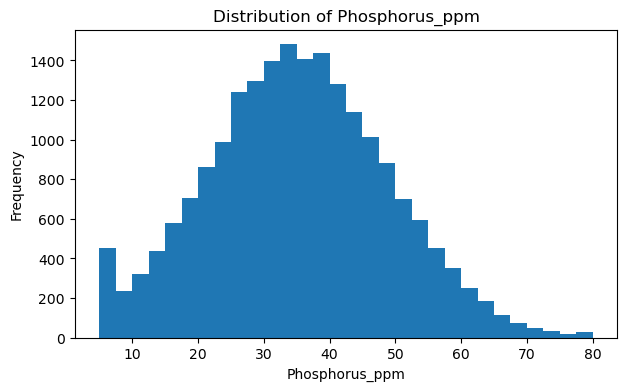

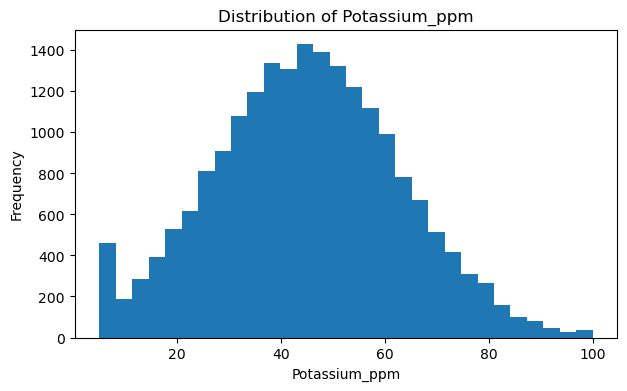

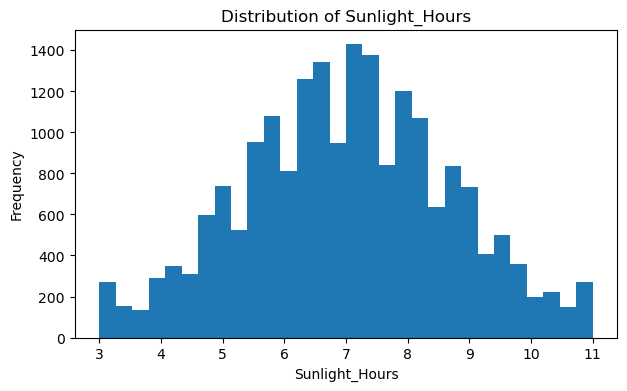

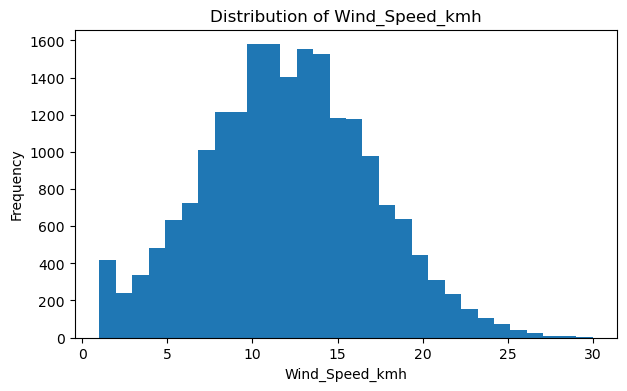

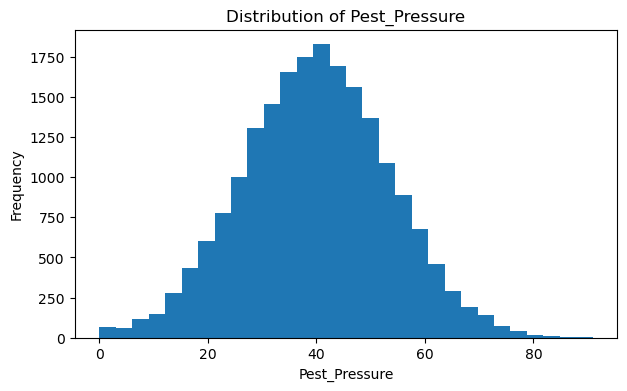

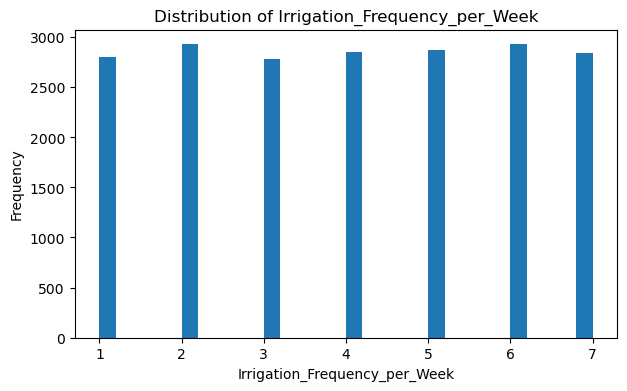

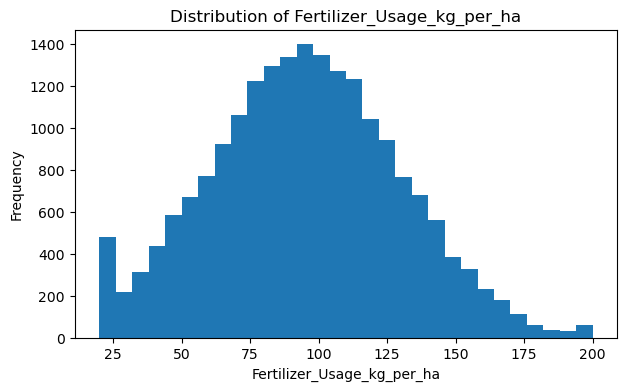

In [12]:
# Numeric feature distributions

numeric_cols_eda = model_df.select_dtypes(include=np.number).columns.tolist()
numeric_cols_eda.remove("Disease_Present")

for col in numeric_cols_eda:
    plt.figure(figsize=(7, 4))
    plt.hist(model_df[col], bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

Disease_Present,0,1
Temperature_C,26.804070,27.109465
Humidity_pct,66.970878,68.692010
Rainfall_mm,122.151729,142.906278
Soil_Moisture_pct,56.029214,61.653170
Soil_pH,6.503029,6.504965
Nitrogen_ppm,55.437630,55.053117
Phosphorus_ppm,35.091826,35.230682
Potassium_ppm,44.820925,45.068330
Sunlight_Hours,6.993521,7.000433
Wind_Speed_kmh,12.094086,12.059094


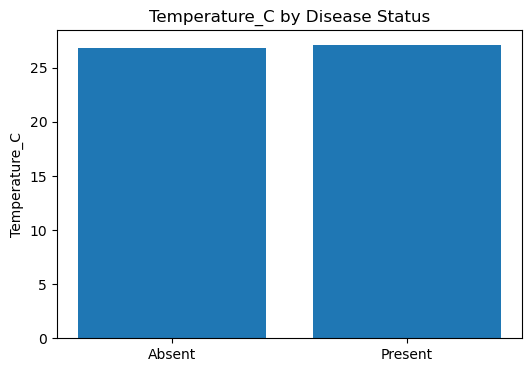

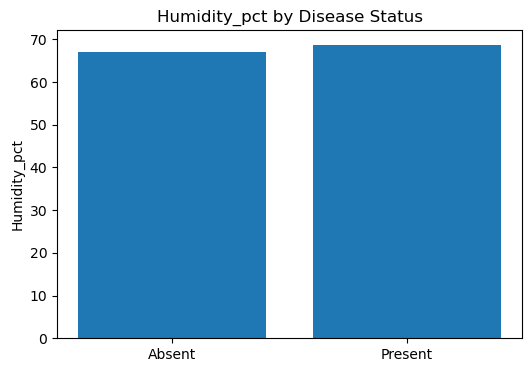

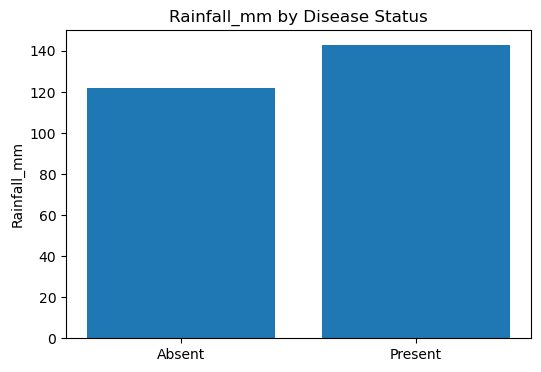

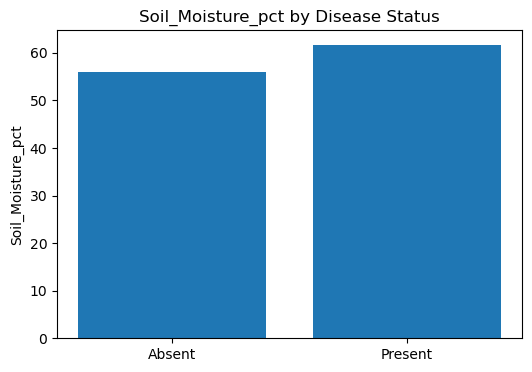

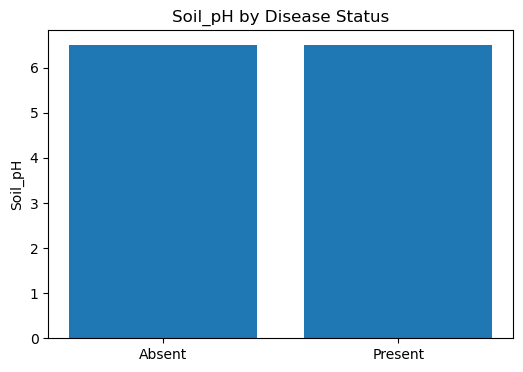

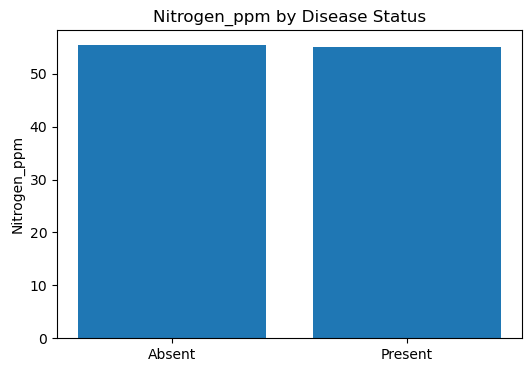

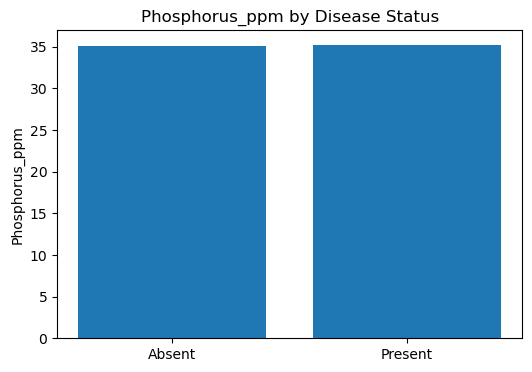

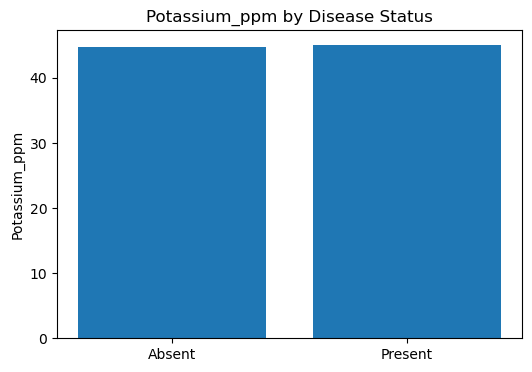

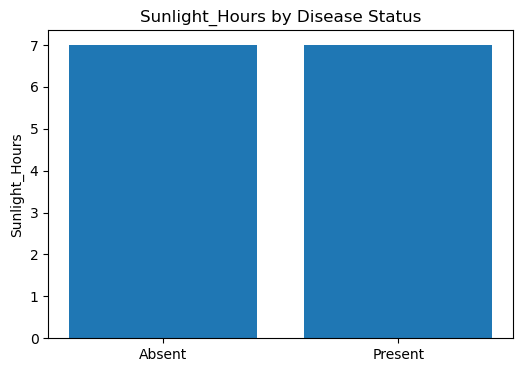

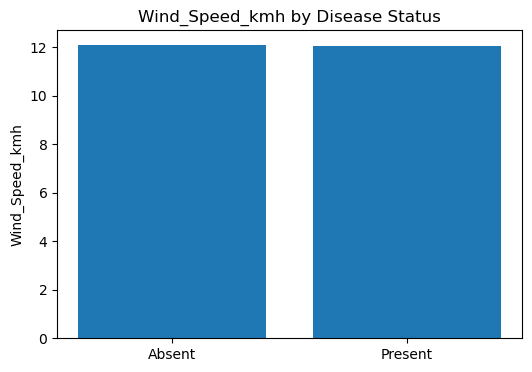

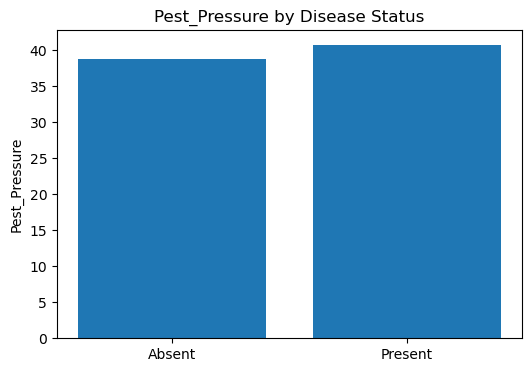

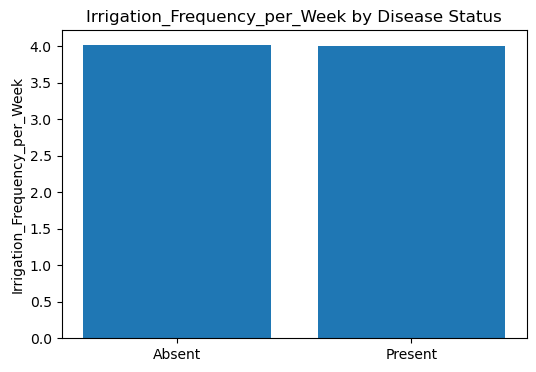

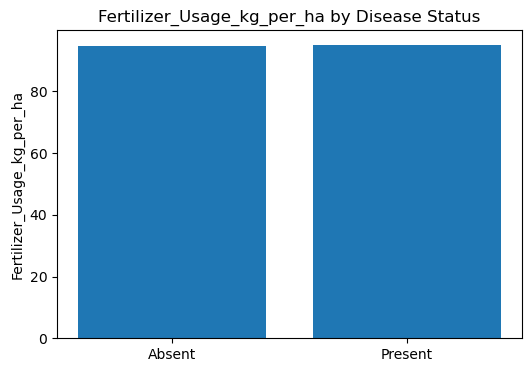

In [13]:
# Mean numeric values by disease status

numeric_cols = model_df.select_dtypes(include=np.number).columns.tolist()
numeric_cols.remove("Disease_Present")

disease_means = model_df.groupby("Disease_Present")[numeric_cols].mean().T

display(disease_means)

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    plt.bar(["Absent", "Present"], disease_means.loc[col])
    plt.title(f"{col} by Disease Status")
    plt.ylabel(col)
    plt.show()

,Correlation with Disease_Present
Rainfall_mm,0.138185
Soil_Moisture_pct,0.135683
Pest_Pressure,0.071992
Humidity_pct,0.062599
Temperature_C,0.030576
Potassium_ppm,0.006864
Phosphorus_ppm,0.005027
Fertilizer_Usage_kg_per_ha,0.003219
Sunlight_Hours,0.002039
Soil_pH,0.001509


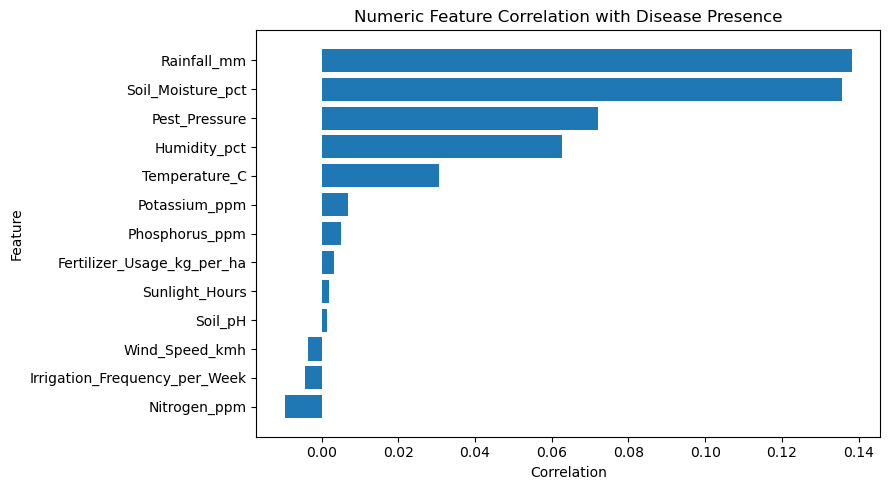

In [13]:
# Correlation of numeric features with the target

# Make sure Disease_Present is NOT included in numeric_cols
numeric_cols = [
    col for col in model_df.select_dtypes(include="number").columns
    if col != "Disease_Present"
]

# Calculate correlation
correlation = (
    model_df[numeric_cols + ["Disease_Present"]]
    .corr()["Disease_Present"]
    .drop("Disease_Present")
    .sort_values(ascending=False)
)

# Display correlation values
display(correlation.to_frame("Correlation with Disease_Present"))

# Plot correlation
plt.figure(figsize=(9, 5))

plt.barh(correlation.index, correlation.values)

plt.title("Numeric Feature Correlation with Disease Presence")
plt.xlabel("Correlation")
plt.ylabel("Feature")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 5. Feature Engineering

In [14]:
# Feature engineering

model_df["Temperature_Humidity_Interaction"] = (model_df["Temperature_C"] * model_df["Humidity_pct"])

model_df["Rainfall_SoilMoisture_Interaction"] = (model_df["Rainfall_mm"] * model_df["Soil_Moisture_pct"])

model_df["Nutrient_Total"] = ( model_df["Nitrogen_ppm"]  + model_df["Phosphorus_ppm"] + model_df["Potassium_ppm"])

model_df["Nutrient_Balance"] = (model_df["Nitrogen_ppm"] / (model_df["Phosphorus_ppm"] + model_df["Potassium_ppm"] + 1))

model_df["Weather_Stress_Index"] = ( model_df["Temperature_C"]  + model_df["Humidity_pct"] / 10 + model_df["Wind_Speed_kmh"] / 5)

model_df["Irrigation_Fertilizer_Interaction"] = ( model_df["Irrigation_Frequency_per_Week"] * model_df["Fertilizer_Usage_kg_per_ha"])



In [15]:
model_df.head()

,Crop_Type,Temperature_C,Humidity_pct,Rainfall_mm,Soil_Moisture_pct,Soil_pH,Nitrogen_ppm,Phosphorus_ppm,Potassium_ppm,Sunlight_Hours,...,Pest_Pressure,Irrigation_Frequency_per_Week,Fertilizer_Usage_kg_per_ha,Disease_Present,Temperature_Humidity_Interaction,Rainfall_SoilMoisture_Interaction,Nutrient_Total,Nutrient_Balance,Weather_Stress_Index,Irrigation_Fertilizer_Interaction
0,Soybean,29.2,78.1,99.9,73.8,6.07,16.3,46.6,70.4,7.6,...,58.0,4,107.4,1,2280.52,7372.62,133.3,0.138136,40.77,429.6
1,Cotton,29.5,59.9,75.9,41.5,6.08,39.6,32.0,71.3,5.7,...,18.6,5,134.7,1,1767.05,3149.85,142.9,0.379674,38.03,673.5
2,Wheat,23.6,73.2,269.4,82.0,5.89,48.3,22.9,51.6,6.4,...,40.6,6,86.5,0,1727.52,22090.80,122.8,0.639735,34.54,519.0
3,Cotton,17.4,87.4,67.3,70.0,7.08,67.3,47.2,56.3,5.4,...,30.5,6,87.8,1,1520.76,4711.00,170.8,0.644019,28.22,526.8
4,Tomato,37.8,71.8,31.3,34.8,5.00,10.0,67.1,55.9,8.1,...,38.0,1,118.7,0,2714.04,1089.24,133.0,0.080645,47.00,118.7


# 6. Feature Selection

In [16]:
target = "Disease_Present"

X = model_df.drop(columns=[target])
y = model_df[target]

categorical_features = ["Crop_Type"]
numeric_features = [col for col in X.columns if col not in categorical_features]

print("Target:", target)
print("\nCategorical Features:")
print(categorical_features)

print("\nNumber of Numeric Features:", len(numeric_features))
print(numeric_features)

Target: Disease_Present

Categorical Features:
['Crop_Type']

Number of Numeric Features: 19
['Temperature_C', 'Humidity_pct', 'Rainfall_mm', 'Soil_Moisture_pct', 'Soil_pH', 'Nitrogen_ppm', 'Phosphorus_ppm', 'Potassium_ppm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Pest_Pressure', 'Irrigation_Frequency_per_Week', 'Fertilizer_Usage_kg_per_ha', 'Temperature_Humidity_Interaction', 'Rainfall_SoilMoisture_Interaction', 'Nutrient_Total', 'Nutrient_Balance', 'Weather_Stress_Index', 'Irrigation_Fertilizer_Interaction']


# 7. Data Splitting

In [17]:
X_train, X_test, y_train, y_test = train_test_split( X, y,test_size=0.20,random_state=42,stratify=y)
print("Training Records:", X_train.shape[0])
print("Testing Records :", X_test.shape[0])

print("\nTraining Target Distribution:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nTesting Target Distribution:")
print(y_test.value_counts(normalize=True).sort_index())

Training Records: 16000
Testing Records : 4000

Training Target Distribution:
Disease_Present
0    0.433688
1    0.566312
Name: proportion, dtype: float64

Testing Target Distribution:
Disease_Present
0    0.43375
1    0.56625
Name: proportion, dtype: float64


In [18]:
# Import required preprocessing tools
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("numeric", StandardScaler(), numeric_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


# 10. Random Forest Classification Model

In [24]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            class_weight="balanced",
            n_jobs=-1
        ))
    ]
)

random_forest_model.fit(X_train, y_train)

rf_pred = random_forest_model.predict(X_test)
rf_prob = random_forest_model.predict_proba(X_test)[:, 1]

print("Random Forest Classification model trained successfully.")

Random Forest Classification model trained successfully.


# 12.  Model Evaluation

In [26]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred, zero_division=0)
rf_recall = recall_score(y_test, rf_pred, zero_division=0)
rf_f1 = f1_score(y_test, rf_pred, zero_division=0)
rf_auc = roc_auc_score(y_test, rf_prob)

final_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "Score": [rf_accuracy, rf_precision, rf_recall, rf_f1, rf_auc]
})

display(final_metrics.style.format({"Score": "{:.4f}"}))

print("Random Forest Classification Report:")
print(classification_report(
    y_test,
    rf_pred,
    target_names=["Disease Absent", "Disease Present"],
    zero_division=0
))

,Metric,Score
0,Accuracy,0.5710
1,Precision,0.5892
2,Recall,0.8009
3,F1 Score,0.6789
4,ROC-AUC,0.5752


Random Forest Classification Report:
                 precision    recall  f1-score   support

 Disease Absent       0.51      0.27      0.35      1735
Disease Present       0.59      0.80      0.68      2265

       accuracy                           0.57      4000
      macro avg       0.55      0.54      0.52      4000
   weighted avg       0.55      0.57      0.54      4000



# 13. Confusion Matrix

Confusion Matrix:
[[ 470 1265]
 [ 451 1814]]


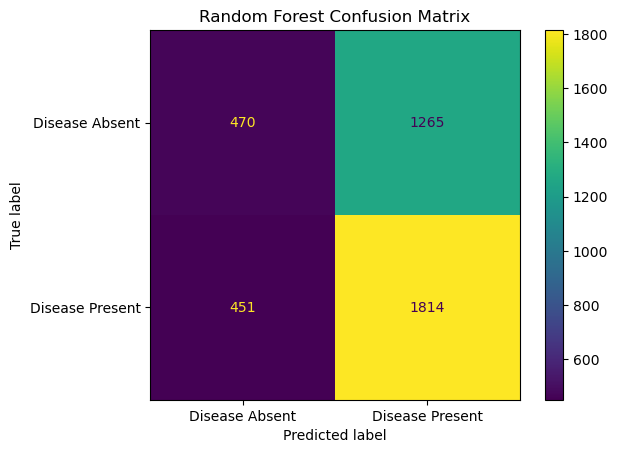

In [27]:
cm = confusion_matrix(y_test, rf_pred)
print("Confusion Matrix:")
print(cm)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Disease Absent", "Disease Present"])
disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

# 14. ROC Curve

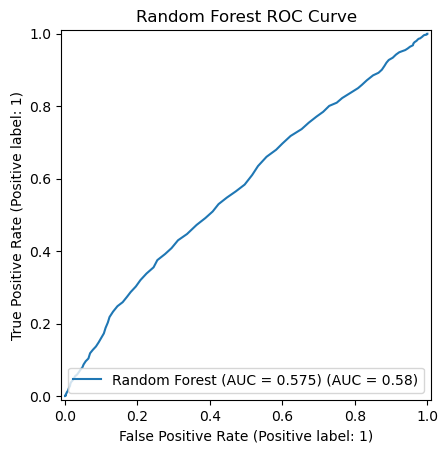

In [28]:
RocCurveDisplay.from_predictions( y_test,rf_prob,name=f"Random Forest (AUC = {rf_auc:.3f})")
plt.title("Random Forest ROC Curve")
plt.show()

# 15. Feature Importance

,Feature,Importance
21,numeric__Rainfall_SoilMoisture_Interaction,0.058315
9,numeric__Rainfall_mm,0.058102
17,numeric__Pest_Pressure,0.057342
25,numeric__Irrigation_Fertilizer_Interaction,0.052706
10,numeric__Soil_Moisture_pct,0.052545
13,numeric__Phosphorus_ppm,0.052515
11,numeric__Soil_pH,0.052446
14,numeric__Potassium_ppm,0.052391
20,numeric__Temperature_Humidity_Interaction,0.052182
19,numeric__Fertilizer_Usage_kg_per_ha,0.052154


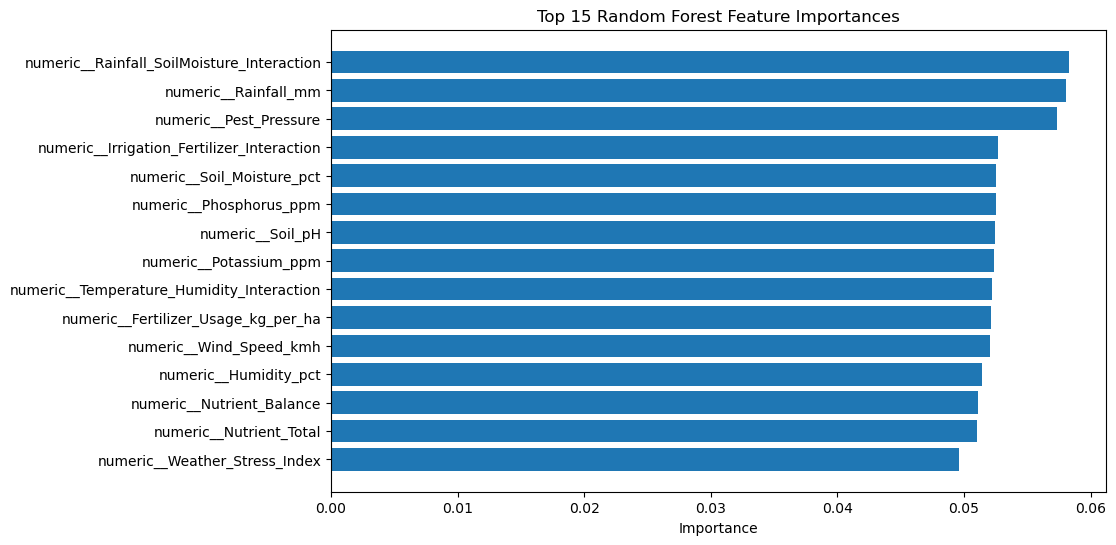

In [29]:
rf_classifier = random_forest_model.named_steps["classifier"]
rf_preprocessor = random_forest_model.named_steps["preprocessor"]

feature_names = rf_preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_classifier.feature_importances_
}).sort_values("Importance", ascending=False)

display(importance_df.head(15))

top_features = importance_df.head(15).sort_values("Importance")

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.show()

# 16. Sample Crop Prediction

In [30]:
def predict_crop_health(input_data):
    input_df = pd.DataFrame(input_data)

    prediction = random_forest_model.predict(input_df)
    probability = random_forest_model.predict_proba(input_df)[:, 1]

    result = input_df.copy()
    result["Predicted_Disease"] = prediction
    result["Disease_Probability_%"] = probability * 100
    result["Health_Status"] = np.where(prediction == 1,"Disease Present","Disease Absent")

    return result

# Demonstrate using the first test observation as an input template
sample_input = X_test.iloc[[0]].copy()

display(predict_crop_health(sample_input.to_dict(orient="records")))

,Crop_Type,Temperature_C,Humidity_pct,Rainfall_mm,Soil_Moisture_pct,Soil_pH,Nitrogen_ppm,Phosphorus_ppm,Potassium_ppm,Sunlight_Hours,...,Fertilizer_Usage_kg_per_ha,Temperature_Humidity_Interaction,Rainfall_SoilMoisture_Interaction,Nutrient_Total,Nutrient_Balance,Weather_Stress_Index,Irrigation_Fertilizer_Interaction,Predicted_Disease,Disease_Probability_%,Health_Status
0,Tomato,39.2,85.2,96.7,65.9,6.09,82.3,57.0,75.4,7.3,...,80.4,3339.84,6372.53,214.7,0.616942,48.74,321.6,1,75.5,Disease Present


In [31]:
# Predict all test records and create an output table

prediction_output = X_test.copy()
prediction_output["Actual_Disease"] = y_test.values
prediction_output["Predicted_Disease"] = rf_pred
prediction_output["Disease_Probability_%"] = rf_prob * 100
prediction_output["Prediction_Correct"] = (prediction_output["Actual_Disease"]== prediction_output["Predicted_Disease"])

display(prediction_output.head(10))

print("Correct predictions:",
      prediction_output["Prediction_Correct"].sum())
print("Total test predictions:",len(prediction_output))

,Crop_Type,Temperature_C,Humidity_pct,Rainfall_mm,Soil_Moisture_pct,Soil_pH,Nitrogen_ppm,Phosphorus_ppm,Potassium_ppm,Sunlight_Hours,...,Temperature_Humidity_Interaction,Rainfall_SoilMoisture_Interaction,Nutrient_Total,Nutrient_Balance,Weather_Stress_Index,Irrigation_Fertilizer_Interaction,Actual_Disease,Predicted_Disease,Disease_Probability_%,Prediction_Correct
4954,Tomato,39.2,85.2,96.7,65.9,6.09,82.3,57.0,75.4,7.3,...,3339.84,6372.53,214.7,0.616942,48.74,321.6,0,1,75.5,False
7233,Wheat,30.4,65.8,245.3,90.0,5.61,39.2,46.5,62.4,8.0,...,2000.32,22077.00,148.1,0.356688,39.06,467.2,0,1,71.0,False
5610,Tomato,29.5,92.5,228.0,90.0,5.41,73.5,60.5,73.0,9.1,...,2728.75,20520.00,207.0,0.546468,40.51,892.5,0,1,58.0,False
14114,Cotton,29.4,74.4,68.6,37.4,6.20,51.2,62.2,56.3,5.5,...,2187.36,2565.64,169.7,0.428452,41.42,155.2,1,0,45.0,False
8183,Rice,31.8,61.6,105.6,49.5,5.87,54.2,30.1,5.0,6.2,...,1958.88,5227.20,89.3,1.501385,40.88,46.1,0,1,52.0,False
11862,Groundnut,30.2,66.0,292.9,90.0,6.59,58.3,59.1,74.3,7.5,...,1993.20,26361.00,191.7,0.433780,38.26,260.0,1,1,69.0,True
18693,Wheat,23.8,67.9,56.8,47.0,7.03,11.7,20.4,49.1,10.8,...,1616.02,2669.60,81.2,0.165957,30.83,83.2,0,1,60.5,False
10578,Maize,29.3,70.1,125.6,67.1,5.91,30.6,29.5,36.1,6.1,...,2053.93,8427.76,96.2,0.459459,38.59,381.0,1,1,55.5,True
13887,Rice,26.5,69.4,45.6,37.0,7.50,59.3,57.4,34.7,4.0,...,1839.10,1687.20,151.4,0.636950,35.92,1048.6,0,0,42.0,True
14791,Soybean,29.1,88.5,68.2,59.0,6.89,116.3,35.8,21.3,7.2,...,2575.35,4023.80,173.4,2.001721,40.11,359.4,0,1,53.0,False


Correct predictions: 2284
Total test predictions: 4000


# 17. Save Model

In [32]:
import joblib

In [33]:
model_filename = "crop_health_random_forest_model.joblib"
joblib.dump(random_forest_model, model_filename)
print("Model saved successfully as:", model_filename)

Model saved successfully as: crop_health_random_forest_model.joblib


In [34]:
# Save test-set predictions
prediction_filename = "crop_health_random_forest_predictions.csv"
prediction_output.to_csv(prediction_filename, index=False)
print("Prediction results saved as:", prediction_filename)

Prediction results saved as: crop_health_random_forest_predictions.csv


# Conclusion

This capstone project successfully developed an end-to-end machine learning classification workflow for crop health prediction.

The project covered data understanding, data quality checking, preprocessing, exploratory data analysis, feature engineering, feature selection, train-test splitting, model comparison, Random Forest classification, evaluation, confusion-matrix analysis, ROC-AUC analysis, feature importance, and sample prediction.


The final model metrics and feature rankings generated in the notebook provide an evidence-based assessment of the model's performance on unseen test data.

#  Future Scope

Potential improvements include:

- Hyperparameter tuning using GridSearchCV or RandomizedSearchCV
- Cross-validation for more robust performance estimation
- XGBoost or other gradient-boosting models
- Real-time sensor integration
- Weather API integration
- Image-based crop disease detection using CNNs
- Mobile or web deployment using Streamlit
- Farm-level disease-risk dashboards
- Integration with IoT soil and weather sensors
- Monitoring model performance after deployment


# References

1. Scikit-learn Documentation
2. Pandas Documentation
3. NumPy Documentation
4. Matplotlib Documentation
5. Python Documentation
6. Random Forest machine-learning literature

---

# Project Summary

**Project Title:** Crop Health Prediction using Random Forest Model.

**Dataset:** Crop health observations with environmental, soil, nutrient, pest, irrigation, fertilizer, and crop-type variables.

**Target:** `Disease_Present`



**Workflow:** Data Collection → Data Understanding → Data Cleaning → EDA → Feature Engineering → Feature Selection → Train-Test Split → Preprocessing → Random Forest Classification → Evaluation → Feature Importance → Prediction → Insights → Conclusion

This project demonstrates a complete machine-learning lifecycle and is structured for an academic ML capstone submission and viva.